In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, applications
from pathlib import Path

# 1. Check for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU is available: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU found. Training will be very slow!")

# 2. Define the automatic path discovery function
def find_dataset_root():
    # We look through /kaggle/input to find where 'train' and 'valid' folders live
    for root, dirs, files in os.walk('/kaggle/input'):
        # Check if both required folders exist in the current directory
        if 'train' in dirs and 'valid' in dirs:
            print(f"✅ Found dataset at: {root}")
            return root
    raise FileNotFoundError("Could not find 'train' and 'valid' folders. Please ensure you added the 'New Plant Diseases Dataset' to the notebook.")

# 3. Configuration Class
class Config:
    img_size = (128, 128)
    batch_size = 32
    epochs_head = 5      # Phase 1: Train the new layers
    epochs_full = 3      # Phase 2: Fine-tune the backbone
    learning_rate = 0.001
    
    # Indentation Fixed: This must be inside the class
    # We call the function here to set the path automatically
    base_path = find_dataset_root()

# 4. Initialize the config
config = Config()

2026-05-15 12:57:50.849463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778849871.041480      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778849871.091170      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778849871.535405      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778849871.535460      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778849871.535463      23 computation_placer.cc:177] computation placer alr

✅ GPU is available: /physical_device:GPU:0
✅ Found dataset at: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


In [2]:
# Training data gets 'Augmentation' to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data ONLY gets 'Rescaling'
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(config.base_path, "train"),
    target_size=config.img_size,
    batch_size=config.batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(config.base_path, "valid"),
    target_size=config.img_size,
    batch_size=config.batch_size,
    class_mode='categorical'
)

num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
print(f"Successfully loaded {num_classes} classes.")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Successfully loaded 38 classes.


In [3]:
def create_model(num_classes):
    base_model = applications.MobileNetV2(
        weights='imagenet', 
        include_top=False, 
        input_shape=(*config.img_size, 3)
    )
    
    # Freeze the backbone
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

model = create_model(num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1778849907.899271      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778849907.905368      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("🚀 Training the classification head...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=config.epochs_head,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
    ]
)

🚀 Training the classification head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1778849915.787572      84 service.cc:152] XLA service 0x7e1214011be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778849915.787608      84 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778849915.787611      84 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778849916.841418      84 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 12:58:45.109913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 12:58:45.246593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778849927.409173      84 device_co

1802/2197 ━━━━━━━━━━━━━━━━━━━━ 1:35 241ms/step - accuracy: 0.6191 - loss: 1.3347

2026-05-15 13:06:11.643608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:06:11.784955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:06:11.920949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6416 - loss: 1.2459

2026-05-15 13:09:10.818569: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:09:10.954477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 643s 285ms/step - accuracy: 0.6416 - loss: 1.2457 - val_accuracy: 0.8590 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 367s 167ms/step - accuracy: 0.8288 - loss: 0.5284 - val_accuracy: 0.8790 - val_loss: 0.3773 - learning_rate: 0.0010
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 369s 168ms/step - accuracy: 0.8466 - loss: 0.4710 - val_accuracy: 0.8800 - val_loss: 0.3587 - learning_rate: 0.0010
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 368s 168ms/step - accuracy: 0.8594 - loss: 0.4336 - val_accuracy: 0.8899 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 377s 171ms/step - accuracy: 0.8659 - loss: 0.4134 - val_accuracy: 0.8902 - val_loss: 0.3333 - learning_rate: 0.0010


In [5]:
# Unfreeze the base model
model.layers[0].trainable = True

# Re-compile with a smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Fine-tuning the full model...")
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=config.epochs_full
)

🚀 Fine-tuning the full model...
Epoch 1/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 494s 204ms/step - accuracy: 0.5680 - loss: 2.3095 - val_accuracy: 0.6531 - val_loss: 1.9949
Epoch 2/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 422s 192ms/step - accuracy: 0.8467 - loss: 0.5134 - val_accuracy: 0.8162 - val_loss: 0.7108
Epoch 3/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 428s 195ms/step - accuracy: 0.8990 - loss: 0.3225 - val_accuracy: 0.8643 - val_loss: 0.4766


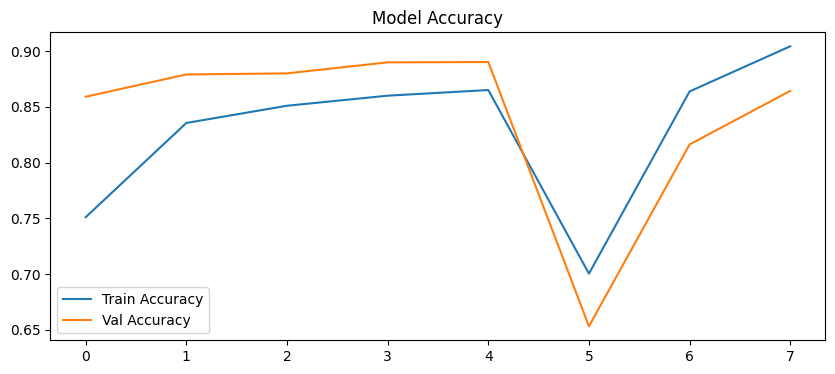

✅ Model saved as plant_disease_model.h5


In [6]:
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Save the model
model.save("plant_disease_model.h5")
print("✅ Model saved as plant_disease_model.h5")